# Task 2.1.10: Task : Object Detection Assignment Part 2

Part 2/2 of the final assignment.

So far you have preprocessed the images and used edge detection to find objects within an image as well as color information from an images HSV color space to detect the same fruits in a mixed image. Now we will expand on this and implement techniques that we have learnt such as Sliding Windows and finally the evaluation of our object detection methods.

In [48]:
# Importing required libraries, which include:
# OpenCV library used for the many tasks in computer vision, from loading images, to processing, detecting, shapes, tracking objects etc.:
import cv2
# Numpy is very useful computation library, here we can use it to compute means:
import numpy as np
# We need the following to show images as plots (x and y axes), later we will use it to draw actual plots too:
import matplotlib.pyplot as plt
# We need the following to draw areas of interest on our plots and images:
import matplotlib.patches as patches
# We need the following to access folders in our OS
import os

### Assignment Task 4 - Object Detection using Sliding Windows

For the following task implement a sliding window that will go over your entire image, allowing for different images to be used. We will then expand on this sliding window by classifying what is in each instance of the sliding window and determining whether it is a fruit and which fruit it is. You must output in some way the location of the sliding window, this can be using a vizualization of the sliding window overlayed on the image or by outputting the coordinates of the current instance of the sliding window.

In [49]:
def sliding_window(image, stepSize, windowSize):
    """
    Slide a window across the image.

    Parameters:
    - image (ndarray): The input image.
    - stepSize (int): The number of pixels the window should move in x and y directions.
    - windowSize (tuple): The width and height of the window.

    Yields:
    - x (int): The x-coordinate of the top-left corner of the current window.
    - y (int): The y-coordinate of the top-left corner of the current window.
    - window (ndarray): The portion of the image within the current window.
    """

    windowWidth, windowHeight = windowSize
    
    for y in range(0, image.shape[0] - windowHeight + 1, stepSize):
        for x in range(0, image.shape[1] - windowWidth + 1, stepSize):

            window = image[y:y + windowHeight, x:x + windowWidth]
            yield (x, y, window)

### Assignment Task 5 - Combining Sliding Windows and detection using color and edges

In this task you must expand on your previous implementation of the sliding window, in order for it to classify whether it is "looking at" a fruit. Once you have succesfully implemented the detection of an object (fruit), try and use color to determine which fruit it is and draw a bounding box with a label around it.

Detected Banana / Lemon from (0, 0) to (1280, 768)


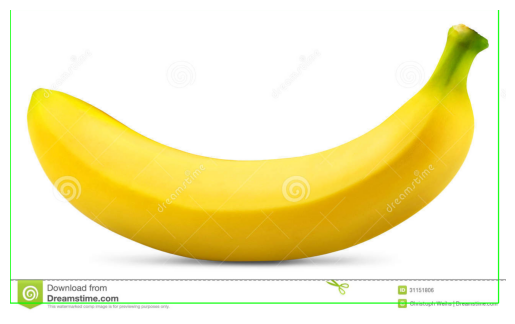

In [50]:

def dominant_color_in_window(window):
    """Find dominant color in a window using histograms in HSV space."""

    hsv = cv2.cvtColor(window, cv2.COLOR_BGR2HSV)

    hue_channel = hsv[:, :, 0]

    hist = cv2.calcHist(
        [hue_channel],
        [0],
        None,
        [180],
        [0, 180]
    )

    dominant_hue = np.argmax(hist)

    return dominant_hue


# Load the preprocessed image
image = cv2.imread("data/fruit/test/banana_79.jpg")

if image is None:
    raise FileNotFoundError("Could not load image. Check the file path.")

output = image.copy()

stepSize = 32
windowSize = (128, 128)

detections = []   # this must be BEFORE the loop

for x, y, window in sliding_window(image, stepSize, windowSize):

    if window.shape[0] != windowSize[1] or window.shape[1] != windowSize[0]:
        continue

    dominant_hue = dominant_color_in_window(window)
    hsv_window = cv2.cvtColor(window, cv2.COLOR_BGR2HSV)

    red_mask1 = cv2.inRange(
        hsv_window,
        np.array([0, 80, 80]),
        np.array([10, 255, 255])
    )

    red_mask2 = cv2.inRange(
        hsv_window,
        np.array([170, 80, 80]),
        np.array([180, 255, 255])
    )

    red_mask = red_mask1 + red_mask2

    yellow_mask = cv2.inRange(
        hsv_window,
        np.array([20, 80, 80]),
        np.array([35, 255, 255])
    )

    orange_mask = cv2.inRange(
        hsv_window,
        np.array([10, 80, 80]),
        np.array([20, 255, 255])
    )

    green_mask = cv2.inRange(
        hsv_window,
        np.array([35, 50, 50]),
        np.array([85, 255, 255])
    )

    red_pixels = cv2.countNonZero(red_mask)
    yellow_pixels = cv2.countNonZero(yellow_mask)
    orange_pixels = cv2.countNonZero(orange_mask)
    green_pixels = cv2.countNonZero(green_mask)

    color_counts = {
        "Apple / Strawberry": red_pixels,
        "Banana / Lemon": yellow_pixels,
        "Orange": orange_pixels,
        "Green Apple / Lime": green_pixels
    }

    label = max(color_counts, key=color_counts.get)
    max_pixels = color_counts[label]

    window_area = windowSize[0] * windowSize[1]
    color_ratio = max_pixels / window_area

    if color_ratio > 0.15:
        detections.append((x, y, x + windowSize[0], y + windowSize[1], label))


# draw only AFTER the loop has finished
if len(detections) > 0:
    x1 = min(box[0] for box in detections)
    y1 = min(box[1] for box in detections)
    x2 = max(box[2] for box in detections)
    y2 = max(box[3] for box in detections)

    labels = [box[4] for box in detections]
    final_label = max(set(labels), key=labels.count)

    cv2.rectangle(output, (x1, y1), (x2, y2), (0, 255, 0), 2)

    cv2.putText(
        output,
        final_label,
        (x1, y1 - 10),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.7,
        (0, 255, 0),
        2
    )

    print(f"Detected {final_label} from ({x1}, {y1}) to ({x2}, {y2})")
else:
    print("No fruit detected.")


plt.imshow(cv2.cvtColor(output, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.show()

### Assignment Task 6 - Evaluating your simple object detection algorithm

In this task you must evaluate your object detection algorithm according to precision, recall and the F1 score. Take an image using your phone or find one on the web - use it to test your object detection algorithm. Does it work as well on unknown images of different fruits?

In [51]:
def evaluate_fruit_detection(image_path, ground_truth_counts):
    """Evaluate fruit detection for a given image and return precision, recall, and F1 score."""

    image = cv2.imread(image_path)

    if image is None:
        raise FileNotFoundError("Could not load image. Check the file path.")

    detected_counts = {
        "apple": 0,
        "lemon": 0,
        "avocado": 0
    }

    # Sliding window parameters
    stepSize = 25
    windowSize = (50, 50)

    # Reuse your sliding_window function from Task 4
    for x, y, window in sliding_window(image, stepSize, windowSize):

        if window.shape[0] != windowSize[1] or window.shape[1] != windowSize[0]:
            continue

        h = dominant_color_in_window(window)

        hsv = cv2.cvtColor(window, cv2.COLOR_BGR2HSV)
        s = np.mean(hsv[:, :, 1])
        v = np.mean(hsv[:, :, 2])

        lemon_range = (20 < h < 40) and (s > 50)
        avocado_range = (v < 50)
        apple_range = (h < 10 or h > 160) and (s > 50)

        if lemon_range:
            detected_counts["lemon"] += 1
        elif avocado_range:
            detected_counts["avocado"] += 1
        elif apple_range:
            detected_counts["apple"] += 1

    results = {}

    for fruit in ground_truth_counts:
        ground_truth = ground_truth_counts[fruit]
        detected = detected_counts.get(fruit, 0)

        true_positive = min(detected, ground_truth)
        false_positive = max(detected - ground_truth, 0)
        false_negative = max(ground_truth - detected, 0)

        if true_positive + false_positive == 0:
            precision = 0
        else:
            precision = true_positive / (true_positive + false_positive)

        if true_positive + false_negative == 0:
            recall = 0
        else:
            recall = true_positive / (true_positive + false_negative)

        if precision + recall == 0:
            f1_score = 0
        else:
            f1_score = 2 * precision * recall / (precision + recall)

        results[fruit] = {
            "ground_truth": ground_truth,
            "detected": detected,
            "true_positive": true_positive,
            "false_positive": false_positive,
            "false_negative": false_negative,
            "precision": precision,
            "recall": recall,
            "f1_score": f1_score
        }

    return results

In [52]:
import glob
import xml.etree.ElementTree as ET
import pandas as pd

def get_ground_truth_counts_from_xml(xml_path):
    """
    Read a Pascal VOC-style XML annotation file and count fruits.
    """

    counts = {
        "apple": 0,
        "lemon": 0,
        "avocado": 0
    }

    tree = ET.parse(xml_path)
    root = tree.getroot()

    for obj in root.findall("object"):
        name = obj.find("name").text.lower().strip()

        if name in counts:
            counts[name] += 1

    return counts

In [53]:


test_folder = "data/fruit/test"

all_results = []

image_paths = glob.glob(os.path.join(test_folder, "*.jpg"))

for image_path in image_paths:
    xml_path = image_path.replace(".jpg", ".xml")

    if not os.path.exists(xml_path):
        print(f"Skipping {image_path}, no XML file found.")
        continue

    ground_truth_counts = get_ground_truth_counts_from_xml(xml_path)

    results = evaluate_fruit_detection(image_path, ground_truth_counts)

    for fruit, values in results.items():
        all_results.append({
            "image": os.path.basename(image_path),
            "fruit": fruit,
            "ground_truth": values["ground_truth"],
            "detected": values["detected"],
            "true_positive": values["true_positive"],
            "false_positive": values["false_positive"],
            "false_negative": values["false_negative"],
            "precision": values["precision"],
            "recall": values["recall"],
            "f1_score": values["f1_score"]
        })

results_df = pd.DataFrame(all_results)

results_df

,image,fruit,ground_truth,detected,true_positive,false_positive,false_negative,precision,recall,f1_score
0,banana_78.jpg,apple,0,10,0,10,0,0.000000,0.0,0.000000
1,banana_78.jpg,lemon,0,73,0,73,0,0.000000,0.0,0.000000
2,banana_78.jpg,avocado,0,0,0,0,0,0.000000,0.0,0.000000
3,banana_93.jpg,apple,0,7,0,7,0,0.000000,0.0,0.000000
4,banana_93.jpg,lemon,0,182,0,182,0,0.000000,0.0,0.000000
...,...,...,...,...,...,...,...,...,...,...
175,apple_87.jpg,lemon,0,0,0,0,0,0.000000,0.0,0.000000
176,apple_87.jpg,avocado,0,0,0,0,0,0.000000,0.0,0.000000
177,apple_93.jpg,apple,1,97,1,96,0,0.010309,1.0,0.020408
178,apple_93.jpg,lemon,0,0,0,0,0,0.000000,0.0,0.000000


In [54]:
summary = results_df.groupby("fruit")[["precision", "recall", "f1_score"]].mean()

summary

,precision,recall,f1_score
fruit,,,
apple,0.006033,0.4,0.011414
avocado,0.000000,0.0,0.000000
lemon,0.000000,0.0,0.000000
